# DLE602 Assessment 1 - Twitter Sentiment Analysis with an N-Gram Model

**Student:** Luis Faria  
**Subject:** DLE602 Deep Learning  
**Assessment:** Assessment 1 - Programming Problems  
**Model:** Bigram probabilistic language model (no deep CNN)  
**Datasets:** STS-Test and STS-Gold - two of the five datasets in Zhao, Gui & Zhang (2018)

This notebook is the *portfolio companion* to the required CLI program (`code/dle602_sentiment_ngram.py`). It reuses that exact code so the numbers here match the submitted source. It runs end-to-end with no manual configuration once `python dataset/download.py` has been run.

## 1. Introduction and model scope

Twitter sentiment analysis classifies short, noisy social-media texts as positive, negative or neutral. Zhao, Gui & Zhang (2018) tackled this with deep convolutional neural networks; this assessment implements the simpler **N-Gram probabilistic language model** required by the brief. Two positive and negative bigram language models are trained from labelled tweets, and the brief's *one-fourth* rule decides the label of each tweet. The same model, preprocessing and decision rule are applied to two data sources so their outcomes can be compared.

In [1]:
import sys
from pathlib import Path

# Reuse the submitted CLI program as a library.
sys.path.insert(0, str(Path.cwd() / 'code'))
import dle602_sentiment_ngram as ng

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
print('Loaded model module:', ng.__name__)

Loaded model module: dle602_sentiment_ngram


## 2. Datasets

Both datasets ship as full tweet text (no Twitter-API hydration), and both are among the paper's five datasets. The key contrast: **STS-Test has a neutral class; STS-Gold does not.** The positive/negative bigram models are trained on a balanced 80k sample of the Sentiment140 training corpus.

In [2]:
train = ng.load_dataset(Path('dataset/sentiment140_train_sample.csv'))
sts_test = ng.load_dataset(Path('dataset/sts_test.csv'))
sts_gold = ng.load_dataset(Path('dataset/sts_gold.csv'))

def dist(name, examples):
    s = pd.Series([e.label for e in examples])
    return {'dataset': name, 'records': len(examples),
            **s.value_counts().to_dict()}

pd.DataFrame([
    dist('train (Sentiment140)', train),
    dist('STS-Test', sts_test),
    dist('STS-Gold', sts_gold),
]).fillna(0).set_index('dataset')

,records,positive,negative,neutral
dataset,,,,
train (Sentiment140),80000,40000,40000,0.0
STS-Test,498,182,177,139.0
STS-Gold,2034,632,1402,0.0


## 3. Preprocessing

Lowercase; replace URLs and @mentions with placeholder tokens; strip the `#` but keep the hashtag word; keep `!`/`?` as sentiment cues. Stop words are kept so the bigram retains short negation context.

In [3]:
sample = sts_test[2].text
print('raw   :', sample)
print('tokens:', ng.preprocess(sample))

raw   : Ok, first assesment of the #kindle2 ...it fucking rocks!!!
tokens: ['ok', 'first', 'assesment', 'of', 'the', 'kindle2', 'it', 'fucking', 'rocks', '!', '!', '!']


## 4. Train the bigram language models

In [4]:
model = ng.build_model(
    Path('dataset/sentiment140_train_sample.csv'),
    n=2, k=1.0, threshold=0.25, margin=0.0,
)

Trained 2-gram model on 80,000 tweets (vocab=49,038, add-k=1.0).


## 5. Evaluate and compare the two data sources

The same trained model is applied to both datasets.

In [5]:
m_test = ng.evaluate(model, sts_test, 'STS-Test')
m_gold = ng.evaluate(model, sts_gold, 'STS-Gold')
metrics = [m_test, m_gold]

rows = []
for m in metrics:
    row = {'dataset': m.name, 'records': m.n_records,
           'accuracy': round(m.accuracy, 4),
           'macro_f1': round(m.macro_f1, 4)}
    for c in ng.LABELS:
        row[f'true_{c}'] = m.true_counts[c]
        row[f'pred_{c}'] = m.pred_counts[c]
    rows.append(row)
pd.DataFrame(rows).set_index('dataset').T

dataset,STS-Test,STS-Gold
records,498.0000,2034.0000
accuracy,0.4518,0.7188
macro_f1,0.4007,0.7262
true_negative,177.0000,1402.0000
pred_negative,186.0000,1110.0000
true_neutral,139.0000,0.0000
pred_neutral,38.0000,136.0000
true_positive,182.0000,632.0000
pred_positive,274.0000,788.0000


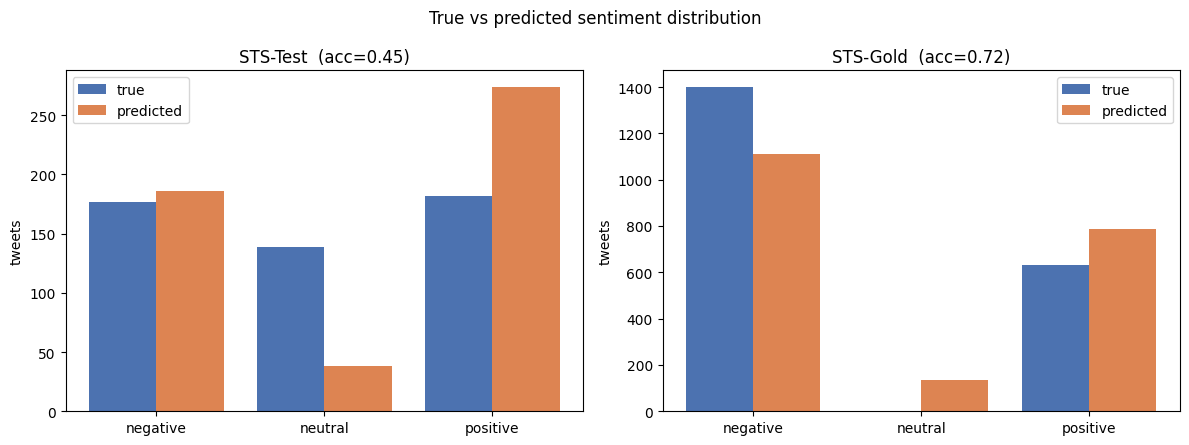

In [6]:
# True vs predicted distribution per dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = range(len(ng.LABELS))
for ax, m in zip(axes, metrics):
    true_vals = [m.true_counts[c] for c in ng.LABELS]
    pred_vals = [m.pred_counts[c] for c in ng.LABELS]
    ax.bar([i - 0.2 for i in x], true_vals, width=0.4, label='true', color='#4C72B0')
    ax.bar([i + 0.2 for i in x], pred_vals, width=0.4, label='predicted', color='#DD8452')
    ax.set_xticks(list(x)); ax.set_xticklabels(ng.LABELS)
    ax.set_title(f'{m.name}  (acc={m.accuracy:.2f})'); ax.set_ylabel('tweets'); ax.legend()
fig.suptitle('True vs predicted sentiment distribution'); fig.tight_layout(); plt.show()

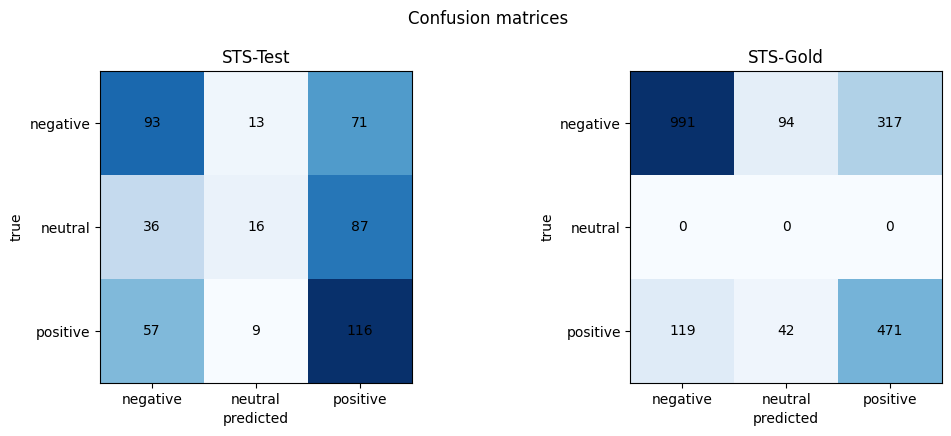

In [7]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, m in zip(axes, metrics):
    matrix = [[m.confusion[t][p] for p in ng.LABELS] for t in ng.LABELS]
    im = ax.imshow(matrix, cmap='Blues')
    ax.set_xticks(range(len(ng.LABELS)), ng.LABELS)
    ax.set_yticks(range(len(ng.LABELS)), ng.LABELS)
    ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title(f'{m.name}')
    for i in range(len(ng.LABELS)):
        for j in range(len(ng.LABELS)):
            ax.text(j, i, matrix[i][j], ha='center', va='center')
fig.suptitle('Confusion matrices'); fig.tight_layout(); plt.show()

## 6. Optional experiment: bigram vs trigram

The brief asks for a single consistent N-Gram order. Bigram is the submitted model; this cell shows why - the trigram is sparser and weaker on short tweets.

In [8]:
comp = []
for n in (2, 3):
    mdl = ng.NGramSentimentModel(n=n, k=1.0, threshold=0.25, margin=0.0)
    mdl.train(train)
    a = ng.evaluate(mdl, sts_test, 'STS-Test')
    b = ng.evaluate(mdl, sts_gold, 'STS-Gold')
    comp.append({'n_gram': n, 'STS-Test acc': round(a.accuracy, 4),
                 'STS-Gold acc': round(b.accuracy, 4)})
pd.DataFrame(comp).set_index('n_gram')

,STS-Test acc,STS-Gold acc
n_gram,,
2,0.4518,0.7188
3,0.4197,0.5497


## 7. Error analysis

Sample misclassifications expose the model's blind spots: sarcasm, emoji, and long-range negation that a local bigram cannot capture.

In [9]:
for m in metrics:
    print(f'# {m.name}')
    for true_label, pred_label, text in m.errors:
        print(f'  true={true_label:<8} pred={pred_label:<8} | {text[:90]}')
    print()

# STS-Test
  true=positive pred=neutral  | @mikefish  Fair enough. But i have the Kindle2 and I think it's perfect  :)
  true=positive pred=negative | @richardebaker no. it is too big. I'm quite happy with the Kindle2.
  true=negative pred=positive | Fuck this economy. I hate aig and their non loan given asses.
  true=positive pred=negative | how can you not love Obama? he makes jokes about himself.
  true=neutral  pred=positive | Check this video out -- President Obama at the White House Correspondents' Dinner http://b

# STS-Gold
  true=negative pred=positive | So dissapointed Taylor Swift doesnt have a Twitter
  true=negative pred=positive | Allergies sucks sometimes. Theres a super adorable 9 month old beagle named Sydney hanging
  true=negative pred=neutral  | Hayfever time  not good!
  true=negative pred=positive | I wish diversity was like one of those musicians with loads of stuff on YouTube, but no  #
  true=negative pred=positive | worked on 5 bone marrow cases today! All + f

## 8. Discussion and conclusion

The same bigram model behaves consistently because identical preprocessing, N-Gram order, smoothing and the 25% rule are used for both sources. Yet the two outcomes differ sharply. On **STS-Gold** (binary, tweet style close to the Sentiment140 training corpus) the model reaches a solid baseline. On **STS-Test** it is much weaker: the three-class task is harder and the model rarely predicts *neutral*, because with smoothing almost every bigram leans positive or negative and the 25% threshold is easily crossed.

The errors confirm the core limitation of N-Grams: local word-pair evidence cannot resolve sarcasm, emoji sentiment or long-range negation. This is why the N-Gram model is a useful, transparent **baseline** but is outperformed by the deep CNN approach of Zhao, Gui & Zhang (2018). See the 500-word report for the full written analysis.